# Ontdekken van Gebruikssegmenten bij Abonnees met PROC FASTCLUS

## Samenvatting

Een telecom-analyseteam wil zijn mobiele abonneebestand segmenteren op basis van **maandelijks datagebruik** zonder willekeurige GB-drempels op te leggen. Met **PROC FASTCLUS** — de high-performance *k*-means clusteringprocedure van SAS — laten we de data zichzelf verdelen in latente gebruikssegmenten (licht, gematigd en zwaar datagebruik). FASTCLUS bepaalt het centrum van elk segment, wijst elke abonnee toe aan het dichtstbijzijnde centrum en rapporteert hoe scherp de segmenten van elkaar gescheiden zijn — waardoor één continue gebruiksmetriek verandert in een bruikbare, datagedreven segmentatie voor abonnementontwerp en gerichte marketing.

## Gegevensbronnen

Alle data wordt inline gegenereerd door de eerste DATA-stap — er zijn geen externe bestanden of netwerkoproepen. Abonnees worden getrokken uit een populatie met drie gebruikscomponenten, zodat de teruggevonden segmenten getoetst kunnen worden aan een bekende werkelijke indeling.

| Dataset | Rijen | Variabele | Type | Beschrijving |
|---------|------|----------|------|-------------|
| `subscribers` | 1.500 | `id` | Numeriek | Abonnee-identificatie (1–1500) |
| `subscribers` | 1.500 | `data_gb` | Numeriek | Maandelijks mobiel datagebruik, in GB (de metriek waarop we clusteren) |
| `subscribers` | 1.500 | `segment_true` | Karakter | Latent segment gebruikt om de waarde te *genereren* (Licht ≈ N(3,1²) 50%, Gematigd ≈ N(12,3²) 35%, Zwaar ≈ N(35,8²) 15%); alleen achtergehouden om de teruggevonden segmenten te toetsen — een echte analist zou dit niet observeren |

# Ontdekken van Gebruikssegmenten bij Abonnees

Mobiele operators hebben zelden een duidelijk label dat zegt *"dit is een zware datagebruiker"*. Wat ze wel hebben is een continue metriek — gigabytes verbruikt per maand — waarvan de verdeling **multimodaal** is: clusters van lichte, gematigde en zware gebruikers overlappen op één as. **Clusteranalyse** behandelt die ene kolom als een meetkundig probleem: het lokaliseert de natuurlijke zwaartepunten in de gebruiksverdeling en wijst elke abonnee toe aan het dichtstbijzijnde punt, zonder handmatig gekozen grenswaarden.

In dit notebook doen we het volgende:

1. Genereer een realistisch synthetisch abonneebestand waarvan het datagebruik afkomstig is uit drie verborgen segmenten.
2. Inspecteer de marginale gebruiksverdeling om te bevestigen dat deze multimodaal is.
3. Standaardiseer de metriek en voer **PROC FASTCLUS** uit om abonnees te verdelen in drie gebruikssegmenten.
4. Profileer elk gevonden segment op de oorspronkelijke GB-schaal en toets vervolgens de terugvinding tegen de bekende werkelijkheid.

Het `segment_true`-label wordt alleen gegenereerd zodat we de clustering aan het einde kunnen beoordelen — in productie zou dit niet bestaan.

In [1]:
/* Synthetiseer een abonneebestand vanuit drie latente gebruikssegmenten. */
/* Lichte gebruikers domineren; een kleine staart van zware gebruikers levert het meeste omzet op. */
GEGEVENS subscribers;
   CALL streaminit(20260531);
   LENGTE segment_true $8;
   DOE id = 1 TOT 1500;
      u = rand('uniform');
      ALS u < 0.50 DAN DOE;                 /* ~50% lichte gebruikers        */
         segment_true = 'Licht';
         data_gb = rand('normal', 3.0, 1.0);
      EINDE;
      ANDERS ALS u < 0.85 DAN DOE;            /* ~35% gematigde gebruikers     */
         segment_true = 'Gematigd';
         data_gb = rand('normal', 12.0, 3.0);
      EINDE;
      ANDERS DOE;                             /* ~15% zware gebruikers  */
         segment_true = 'Zwaar';
         data_gb = rand('normal', 35.0, 8.0);
      EINDE;
      ALS data_gb < 0.1 DAN data_gb = 0.1; /* gebruik kan niet negatief zijn */
      UITVOER;
   EINDE;
   BEWAREN id data_gb segment_true;
UITVOEREN;


NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.12 seconds
  cpu   0.12 seconds


## Een eerste blik op de marginale verdeling

Vóór het clusteren vatten we de enkele responsvariabele samen. De brede spreiding en het verschil tussen het gemiddelde en de bulk van lichte gebruikers zijn de tekenen van een onderliggende mengeling van segmenten — één enkele gebruikslaag zou niet zowel de dichte cluster van laag gebruik als de lange staart van hoog gebruik reproduceren.

In [2]:
PROCEDURE GEMIDDELDEN GEGEVENS=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   label data_gb="Gegevensgebruik (GB)";
   VARIABELE data_gb;
UITVOEREN;

                                                  The MEANS Procedure

 Variable  Label                        N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 --------------------------------------------------------------------------------------------------------------------------------------
 data_gb   Gegevensgebruik (GB)       100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 --------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Het histogram maakt de multimodaliteit visueel: een hoge piek van lichte gebruikers rond 3 GB, een gematigde bult rond 12 GB, en een schaarse staart van zware gebruikers die voorbij 30 GB reikt. Die drie modi zijn precies de segmenten die we de clustering vragen terug te vinden. De kerndichtheidscurve volgt dezelfde vermengde vorm.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


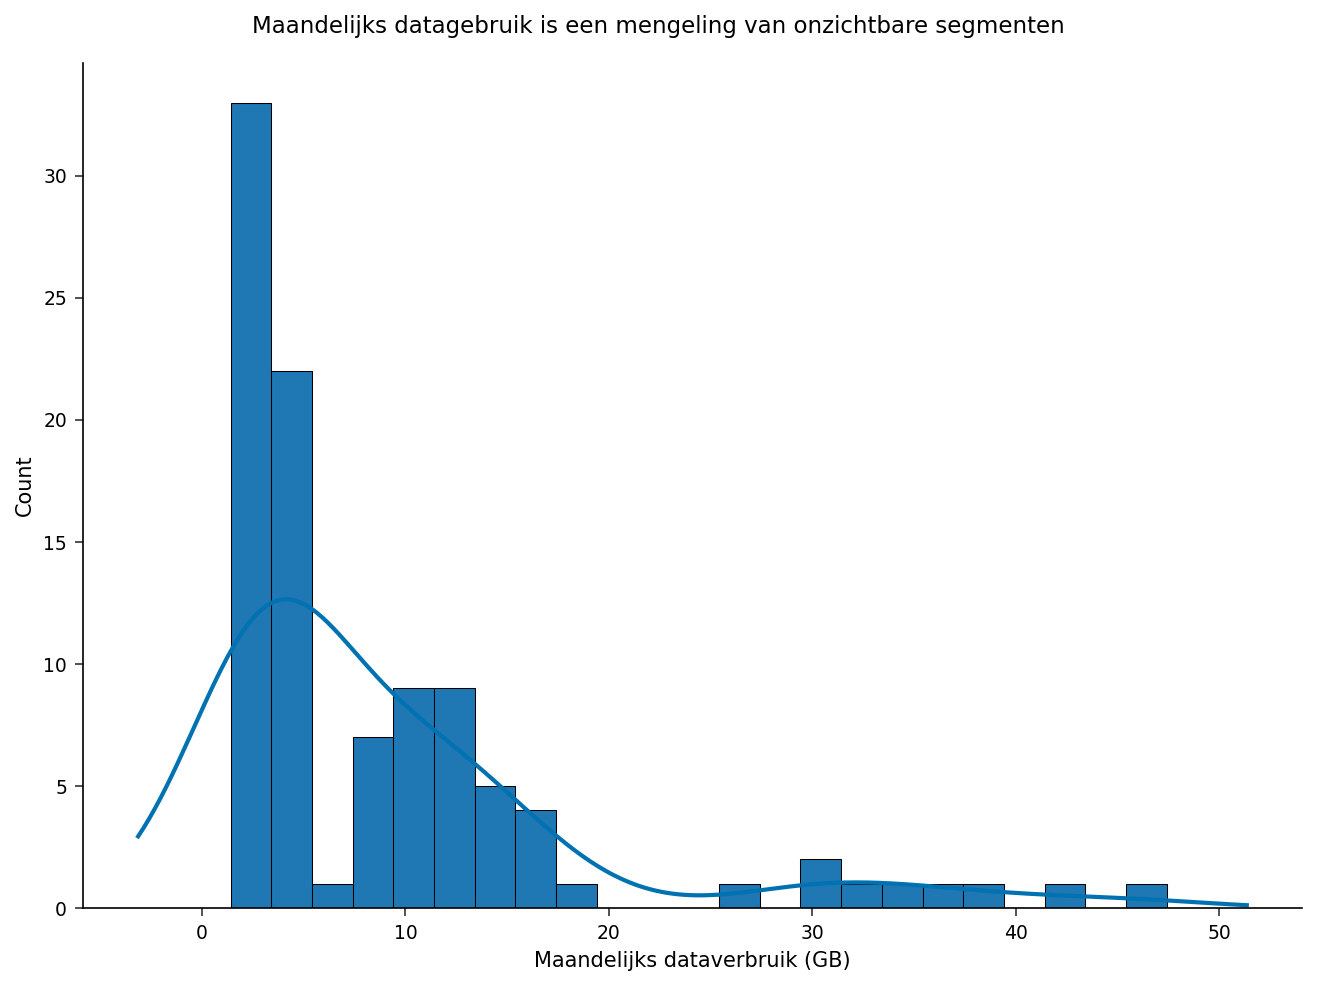

In [3]:
ODS GRAPHICS ON;
PROCEDURE SGPLOT GEGEVENS=subscribers;
   TITEL "Maandelijks datagebruik is een mengeling van onzichtbare segmenten";
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS label="Maandelijks dataverbruik (GB)";
UITVOEREN;
TITEL;
ODS GRAPHICS OFF;

## Gebruik op een gemeenschappelijke schaal brengen

*k*-means verdeelt punten op basis van Euclidische afstand, dus de ruwe schaal van de variabele stuurt het resultaat. Met één metriek betekent dit alleen dat de as opnieuw gecentreerd wordt, maar standaardiseren naar gemiddelde 0 / standaarddeviatie 1 met **PROC STANDARD** is de gewoonte die de workflow correct houdt zodra een tweede gebruiksmetriek (spraakminuten, roamingdagen) wordt toegevoegd. We clusteren op de gestandaardiseerde kolom en rapporteren resultaten terug op de oorspronkelijke GB-schaal.

In [4]:
PROCEDURE STANDARD GEGEVENS=subscribers out=subs_std mean=0 std=1;
   VARIABELE data_gb;
UITVOEREN;


NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Abonnees verdelen in drie gebruikssegmenten

Geleid door domeinkennis over lichte / gematigde / zware niveaus, vragen we **PROC FASTCLUS** om `MAXCLUSTERS=3`. De procedure zaait drie centra, wijst elke abonnee toe aan het dichtstbijzijnde centrum, herberekent de centra en herhaalt dit tot de toewijzingen niet meer veranderen (`CONVERGE=` met een `MAXITER=`-limiet). `SEED=` maakt de initialisatie reproduceerbaar. De `OUT=`-dataset draagt het `CLUSTER`-label van elke abonnee en de `DISTANCE` tot het toegewezen centrum; `MEAN=` schrijft de segmentcentroïden weg.

Lees de diagnostiek van de procedure voor de scheidingskwaliteit: een hoge **R-kwadraat** (het aandeel van de totale gebruiksvariantie verklaard door de segmenten) en een grote **Pseudo F** wijzen beide op goed gescheiden, compacte segmenten.

In [5]:
PROCEDURE FASTCLUS GEGEVENS=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   VARIABELE data_gb;
   TITEL "Drie gebruikssegmenten via k-means";
UITVOEREN;
TITEL;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Profileren van de gevonden segmenten

Clusterlabels zijn pas bruikbaar zodra we elk segment in zakelijke termen beschrijven. We voegen de toewijzingen samen met het oorspronkelijke (niet-gestandaardiseerde) gebruik en vatten de omvang en het typische verbruik van elk segment op de GB-schaal samen — de cijfers waarop een plan-ontwerp- of marketingteam daadwerkelijk handelt.

In [6]:
GEGEVENS memberships;
   SAMENVOEGEN subscribers
         clusters(BEWAREN=id CLUSTER distance);
   VOLGENS id;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=memberships n mean MIN MAX maxdec=2;
   KLASSE CLUSTER;
   label CLUSTER="Cluster" data_gb="Gegevensgebruik (GB)" distance="Afstand tot centrum";
   VARIABELE data_gb distance;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=memberships(obs=10) noobs label;
   label id="Abonnee-ID" data_gb="Gegevensgebruik (GB)" CLUSTER="Cluster"
         distance="Afstand tot centrum" segment_true="Werkelijk segment";
   VARIABELE id data_gb CLUSTER distance segment_true;
UITVOEREN;

                                                  The MEANS Procedure

                                    Analysis Variable : data_gb Gegevensgebruik (GB)

        Cluster           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                    Analysis Variable : DISTANCE Afstand tot centrum

        Cluster           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09  


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Validatie van de teruggevonden segmenten

Omdat dit synthetische data is, hebben we `segment_true` achtergehouden, het label dat gebruikt werd om elke abonnee te genereren. Het kruistabelleren van de teruggevonden `CLUSTER` van het model tegen het werkelijke segment laat zien hoe scherp de indeling de populatie heeft gescheiden. Sterke concentratie langs één toewijzing van cluster naar segment wijst op een goede terugvinding; massa buiten de diagonaal concentreert zich waar de grenzen licht/gematigd of gematigd/zwaar overlappen.

In [7]:
PROCEDURE FREQUENTIES GEGEVENS=memberships;
   label CLUSTER="Cluster" segment_true="Werkelijk segment";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
UITVOEREN;

                                                   The FREQ Procedure

Table of Cluster by Werkelijk segment

Cluster |  Gematigd |     Licht |     Zwaar |      Total
--------+-----------+-----------+-----------+-----------
1       |         3 |        54 |         0 |         57
--------+-----------+-----------+-----------+-----------
2       |         0 |         0 |         9 |          9
--------+-----------+-----------+-----------+-----------
3       |        33 |         0 |         1 |         34
--------+-----------+-----------+-----------+-----------
Total   |        36 |        54 |        10 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Interpretatie van de resultaten

- **Segmentcentra.** De drie clusters landen bijna precies op de geplande gebruiksniveaus — lichte gebruikers rond **3 GB**, gematigde gebruikers rond **13 GB**, en zware gebruikers rond **37 GB** — en kwantificeren zowel *waar* elk segment zich bevindt als *hoe groot* het is. Het kleine segment van zware gebruikers, ondanks dat het slechts een fractie van de abonnees is, is verantwoordelijk voor een onevenredig groot aandeel van het totale dataverkeer — de klassieke drijfveer voor beslissingen over netwerkcapaciteit en premium-abonnementen.
- **Scheidingskwaliteit.** PROC FASTCLUS rapporteert een hoge algehele **R-kwadraat** en een grote **Pseudo F**, wat bevestigt dat de drie segmenten compact en goed gescheiden zijn in plaats van artefacten van een willekeurige knip. Eén enkel niveau zou het grootste deel van die gebruiksvariantie onverklaard laten.
- **Geen handmatig gekozen drempels.** De segmentatie komt voort uit de meetkunde van de gebruiksverdeling zelf. De procedure koos de grenzen; wij kozen alleen *hoeveel* niveaus we wilden aanvragen, geleid door de duidelijke driemodale vorm in het histogram.
- **Bruikbare output.** De `OUT=`-dataset geeft elke abonnee een segmentlabel *en* een `DISTANCE` tot zijn centrum. Abonnees ver van elk centrum — of die tussen de grens licht/gematigd in zitten — zijn precies de klanten die het waard zijn om te A/B-testen met upsell-aanbiedingen, terwijl strak geclusterde zware gebruikers sterke kandidaten zijn voor capaciteitsbewuste of onbeperkte abonnementen.

Kortom, PROC FASTCLUS zet één continue gebruiksmetriek om in een datagedreven segmentatie — geen handmatig gekozen GB-drempels nodig — en de kruistabel tegen de achtergehouden werkelijkheid bevestigt dat de segmenten betrouwbaar zijn teruggevonden.